In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft
import plotly.graph_objects as go
import plotly.express as px

In [2]:
loaded_data_npy = np.load('identified_eigdata.npy', allow_pickle=True).item()
Phi_id = loaded_data_npy['Phi_id']
freq_id = loaded_data_npy['freq_id']
ind_d = loaded_data_npy['ind_d']

print(Phi_id.shape)

(35, 6)


In [3]:
n_modes = len(freq_id)
print(n_modes)

6


Text(0, 0.5, 'Mode Number')

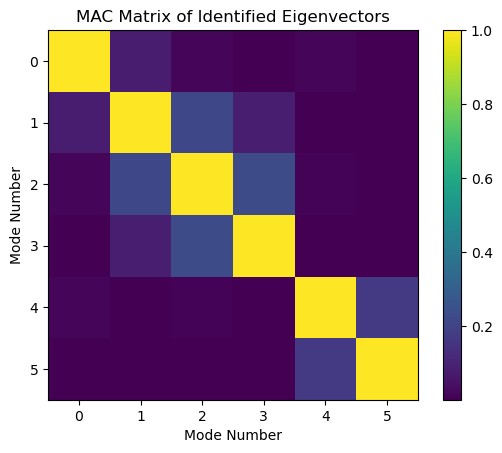

In [4]:
# Calculate and plot the global MAC matrix
MAC = np.zeros((n_modes, n_modes))
for i in range(n_modes):
    for j in range(n_modes):
        MAC[i, j] = (np.abs(Phi_id[:, i].conj().T @ Phi_id[:, j]))**2 / ((Phi_id[:, i].conj().T @ Phi_id[:, i]) * (Phi_id[:, j].conj().T @ Phi_id[:, j]))

# Plot the MAC matrix: Check if the off-diagonal elements are close to zero
fig = plt.imshow(MAC)
plt.colorbar(fig)
plt.title('MAC Matrix of Identified Eigenvectors')
plt.xlabel('Mode Number')
plt.ylabel('Mode Number')

# Attempt to plot MAC for identified and modelled modes

In [5]:
Phi = np.load('Phi.npy', allow_pickle=True)
print(Phi.shape)
Phi_m = Phi[ind_d, :]
Phi_m = Phi_m / np.linalg.norm(Phi_m, axis=0)
print(Phi_m.shape)

(285, 255)
(35, 255)


In [6]:
MAC = np.zeros((Phi_id.shape[1] + 5, Phi_id.shape[1]))   # Initialize MAC matrix
for i in range(Phi_id.shape[1] + 5):                     # Index over computed modes (larger)
    for j in range(Phi_id.shape[1]):                     # Index over identified modes
        numerator = np.abs(np.conj(Phi_m[:, i]) @ Phi_id[:, j])**2
        denominator = (np.conj(Phi_m[:, i]) @ Phi_m[:, i]) * (np.conj(Phi_id[:, j]) @ Phi_id[:, j])
        MAC[i, j] = numerator / denominator

# Plot the MAC matrix: Check if the off-diagonal elements are close to zero
fig = px.imshow(MAC)
fig.show()

In [7]:
# Calculate and plot the global MAC matrix
MAC = np.zeros((n_modes, n_modes))
for i in range(n_modes):
    for j in range(n_modes):
        MAC[i, j] = (np.abs(Phi_id[:, i].conj().T @ Phi_id[:, j]))**2 / ((Phi_id[:, i].conj().T @ Phi_id[:, i]) * (Phi_id[:, j].conj().T @ Phi_id[:, j]))

# Plot the MAC matrix: Check if the off-diagonal elements are close to zero
fig = px.imshow(MAC)
fig.show()


In [8]:
import pandas as pd

freqs_model = np.array([0.27, 1.22, 2.47, 4.64, 6.31, 8.83])
df_freqs = pd.DataFrame({'Modelled Frequency': freqs_model, 'Identified Frequency': freq_id})
df_freqs['error %'] = np.round(np.abs(df_freqs['Modelled Frequency'] - df_freqs['Identified Frequency']) / df_freqs['Modelled Frequency'] * 100, 2)

In [9]:
df_freqs

,Modelled Frequency,Identified Frequency,error %
0,0.27,0.32,18.52
1,1.22,1.03,15.57
2,2.47,3.08,24.70
3,4.64,4.76,2.59
4,6.31,10.93,73.22
5,8.83,13.60,54.02
